In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from sklearn.metrics import precision_score, recall_score, f1_score
from IPython.display import display, clear_output

In [165]:
path = r"C:\\Users\samik\AppData\\Local\\Temp\\a9a9a8a6-1c1d-437b-aaa1-6b22b59bfa61_weatherAUS (3).zip.weatherAUS (3).zip\\weatherAUS.csv"
df=pd.read_csv(path)
df


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [166]:
df = df.drop(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'], axis=1)
df.dropna(subset=['RainToday', 'RainTomorrow'], inplace=True)
df[['RainToday', 'RainTomorrow']] = df[['RainToday', 'RainTomorrow']].replace({'Yes': 1.0, 'No': 0.0})
df = df.drop(['Temp3pm', 'Temp9am', 'Pressure3pm', 'Evaporation'], axis=1)
df.fillna(df.mean(), inplace=True)
df

C:\Users\samik\AppData\Local\Temp\ipykernel_12292\490442678.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['RainToday', 'RainTomorrow']] = df[['RainToday', 'RainTomorrow']].replace({'Yes': 1.0, 'No': 0.0})


,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Cloud9am,Cloud3pm,RainToday,RainTomorrow
0,13.4,22.9,0.6,7.63054,44.0,20.0,24.0,71.0,22.0,1007.7,8.000000,4.49925,0.0,0.0
1,7.4,25.1,0.0,7.63054,44.0,4.0,22.0,44.0,25.0,1010.6,4.431161,4.49925,0.0,0.0
2,12.9,25.7,0.0,7.63054,46.0,19.0,26.0,38.0,30.0,1007.6,4.431161,2.00000,0.0,0.0
3,9.2,28.0,0.0,7.63054,24.0,11.0,9.0,45.0,16.0,1017.6,4.431161,4.49925,0.0,0.0
4,17.5,32.3,1.0,7.63054,41.0,7.0,20.0,82.0,33.0,1010.8,7.000000,8.00000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,3.5,21.8,0.0,7.63054,31.0,15.0,13.0,59.0,27.0,1024.7,4.431161,4.49925,0.0,0.0
145455,2.8,23.4,0.0,7.63054,31.0,13.0,11.0,51.0,24.0,1024.6,4.431161,4.49925,0.0,0.0
145456,3.6,25.3,0.0,7.63054,22.0,13.0,9.0,56.0,21.0,1023.5,4.431161,4.49925,0.0,0.0
145457,5.4,26.9,0.0,7.63054,37.0,9.0,9.0,53.0,24.0,1021.0,4.431161,4.49925,0.0,0.0


In [167]:
df['EncodedRainTomorrow'] = df['RainTomorrow'].apply(lambda x: 1 if x == 1.0 else 0)
df = df.drop(['RainToday', 'RainTomorrow'], axis=1)
df

,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Cloud9am,Cloud3pm,EncodedRainTomorrow
0,13.4,22.9,0.6,7.63054,44.0,20.0,24.0,71.0,22.0,1007.7,8.000000,4.49925,0
1,7.4,25.1,0.0,7.63054,44.0,4.0,22.0,44.0,25.0,1010.6,4.431161,4.49925,0
2,12.9,25.7,0.0,7.63054,46.0,19.0,26.0,38.0,30.0,1007.6,4.431161,2.00000,0
3,9.2,28.0,0.0,7.63054,24.0,11.0,9.0,45.0,16.0,1017.6,4.431161,4.49925,0
4,17.5,32.3,1.0,7.63054,41.0,7.0,20.0,82.0,33.0,1010.8,7.000000,8.00000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,3.5,21.8,0.0,7.63054,31.0,15.0,13.0,59.0,27.0,1024.7,4.431161,4.49925,0
145455,2.8,23.4,0.0,7.63054,31.0,13.0,11.0,51.0,24.0,1024.6,4.431161,4.49925,0
145456,3.6,25.3,0.0,7.63054,22.0,13.0,9.0,56.0,21.0,1023.5,4.431161,4.49925,0
145457,5.4,26.9,0.0,7.63054,37.0,9.0,9.0,53.0,24.0,1021.0,4.431161,4.49925,0


In [168]:
def replace_nan(df):
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            median = df[col].median()
            df[col] = df[col].fillna(median)
        elif df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')
    return df
df=replace_nan(df)
df

,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Cloud9am,Cloud3pm,EncodedRainTomorrow
0,13.4,22.9,0.6,7.63054,44.0,20.0,24.0,71.0,22.0,1007.7,8.000000,4.49925,0
1,7.4,25.1,0.0,7.63054,44.0,4.0,22.0,44.0,25.0,1010.6,4.431161,4.49925,0
2,12.9,25.7,0.0,7.63054,46.0,19.0,26.0,38.0,30.0,1007.6,4.431161,2.00000,0
3,9.2,28.0,0.0,7.63054,24.0,11.0,9.0,45.0,16.0,1017.6,4.431161,4.49925,0
4,17.5,32.3,1.0,7.63054,41.0,7.0,20.0,82.0,33.0,1010.8,7.000000,8.00000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,3.5,21.8,0.0,7.63054,31.0,15.0,13.0,59.0,27.0,1024.7,4.431161,4.49925,0
145455,2.8,23.4,0.0,7.63054,31.0,13.0,11.0,51.0,24.0,1024.6,4.431161,4.49925,0
145456,3.6,25.3,0.0,7.63054,22.0,13.0,9.0,56.0,21.0,1023.5,4.431161,4.49925,0
145457,5.4,26.9,0.0,7.63054,37.0,9.0,9.0,53.0,24.0,1021.0,4.431161,4.49925,0


In [169]:
features = df.drop(columns=['EncodedRainTomorrow'])
for column in features.columns:
    mean = features[column].mean()
    std = features[column].std()
    df[column] = (features[column] - mean) / std
    
df

,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Cloud9am,Cloud3pm,EncodedRainTomorrow
0,0.190072,-0.047155,-0.206726,3.239884e-16,0.306849,0.678821,0.615790,0.114615,-1.433267,-1.474929,1.562366e+00,8.420917e-16,0
1,-0.748421,0.262410,-0.277605,3.239884e-16,0.306849,-1.128506,0.386397,-1.309386,-1.287260,-1.045248,7.776534e-16,8.420917e-16,0
2,0.111865,0.346837,-0.277605,3.239884e-16,0.459151,0.565863,0.845183,-1.625831,-1.043915,-1.489746,7.776534e-16,-1.184783e+00,0
3,-0.466873,0.670473,-0.277605,3.239884e-16,-1.216172,-0.337800,-1.104659,-1.256645,-1.725281,-0.008086,7.776534e-16,8.420917e-16,0
4,0.831376,1.275533,-0.159474,3.239884e-16,0.078396,-0.789632,0.157004,0.694763,-0.897908,-1.015615,1.124586e+00,1.659550e+00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,-1.358442,-0.201938,-0.277605,3.239884e-16,-0.683115,0.114031,-0.645873,-0.518275,-1.189922,1.043892,7.776534e-16,8.420917e-16,0
145455,-1.467932,0.023200,-0.277605,3.239884e-16,-0.683115,-0.111884,-0.875266,-0.940201,-1.335929,1.029075,7.776534e-16,8.420917e-16,0
145456,-1.342800,0.290552,-0.277605,3.239884e-16,-1.368474,-0.111884,-1.104659,-0.676497,-1.481936,0.866093,7.776534e-16,8.420917e-16,0
145457,-1.061252,0.515691,-0.277605,3.239884e-16,-0.226208,-0.563716,-1.104659,-0.834719,-1.335929,0.495678,7.776534e-16,8.420917e-16,0


In [170]:
def one_hot_encode(df, columns):
    for col in columns:
        dummies = pd.get_dummies(df[col].fillna('Unknown'), prefix=col)
        df = pd.concat([df.drop(col, axis=1), dummies], axis=1)
    return df
string_columns=df.select_dtypes(include='object').columns.tolist()
df=one_hot_encode(df,string_columns)
df

,MinTemp,MaxTemp,Rainfall,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Cloud9am,Cloud3pm,EncodedRainTomorrow
0,0.190072,-0.047155,-0.206726,3.239884e-16,0.306849,0.678821,0.615790,0.114615,-1.433267,-1.474929,1.562366e+00,8.420917e-16,0
1,-0.748421,0.262410,-0.277605,3.239884e-16,0.306849,-1.128506,0.386397,-1.309386,-1.287260,-1.045248,7.776534e-16,8.420917e-16,0
2,0.111865,0.346837,-0.277605,3.239884e-16,0.459151,0.565863,0.845183,-1.625831,-1.043915,-1.489746,7.776534e-16,-1.184783e+00,0
3,-0.466873,0.670473,-0.277605,3.239884e-16,-1.216172,-0.337800,-1.104659,-1.256645,-1.725281,-0.008086,7.776534e-16,8.420917e-16,0
4,0.831376,1.275533,-0.159474,3.239884e-16,0.078396,-0.789632,0.157004,0.694763,-0.897908,-1.015615,1.124586e+00,1.659550e+00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,-1.358442,-0.201938,-0.277605,3.239884e-16,-0.683115,0.114031,-0.645873,-0.518275,-1.189922,1.043892,7.776534e-16,8.420917e-16,0
145455,-1.467932,0.023200,-0.277605,3.239884e-16,-0.683115,-0.111884,-0.875266,-0.940201,-1.335929,1.029075,7.776534e-16,8.420917e-16,0
145456,-1.342800,0.290552,-0.277605,3.239884e-16,-1.368474,-0.111884,-1.104659,-0.676497,-1.481936,0.866093,7.776534e-16,8.420917e-16,0
145457,-1.061252,0.515691,-0.277605,3.239884e-16,-0.226208,-0.563716,-1.104659,-0.834719,-1.335929,0.495678,7.776534e-16,8.420917e-16,0


In [171]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(0.8 * len(df))
df_train, df_test = df[:train_size], df[train_size:]
y_train, y_test = df_train['EncodedRainTomorrow'].to_numpy(), df_test['EncodedRainTomorrow'].to_numpy()
X_train, X_test = df_train.drop("EncodedRainTomorrow", axis=1).to_numpy(), df_test.drop("EncodedRainTomorrow", axis=1).to_numpy()

In [172]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

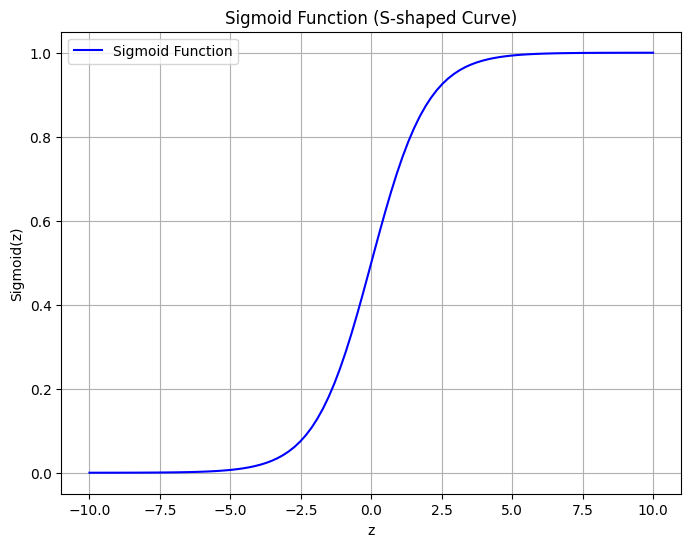

In [173]:
z_values = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z_values)
plt.figure(figsize=(8, 6))
plt.plot(z_values, sigmoid_values, label='Sigmoid Function', color='blue')
plt.title('Sigmoid Function (S-shaped Curve)')
plt.xlabel('z')
plt.ylabel('Sigmoid(z)')
plt.grid(True)
 
plt.legend()
plt.show()

In [174]:
def loss(y, y_pred):
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

In [175]:
def predict(X, weights, b):
    f_wb = np.dot(X, weights) + b
    return [1 if sigmoid(z) >= 0.5 else 0 for z in f_wb]

In [176]:
def compute_cost_regularized(X, y, w, b, lambda_):
    m, n = X.shape
    cost = 0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i] * np.log(f_wb_i) - (1 - y[i]) * np.log(1 - f_wb_i)
    cost /= m
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)
    return cost + reg_cost

In [177]:
def compute_gradient_regularized(X, y, w, b, lambda_):
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0
    for i in range(m):
        z = np.dot(X[i], w) + b
        err_i = sigmoid(z) - y[i]
        dj_dw += err_i * X[i]
        dj_db += err_i
    dj_dw /= m
    dj_db /= m
    dj_dw += (lambda_ / m) * w
    return dj_dw, dj_db

In [178]:
def gradient_descent(X, y, w_in, b_in, alpha, lambda_, num_iters):
    w = w_in
    b = b_in
    LOSS_hist = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_regularized(X, y, w, b, lambda_)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        cost = compute_cost_regularized(X, y, w, b, lambda_)
        LOSS_hist.append(cost)
        
        clear_output(wait=True)
        display(f'Iteration {i+1}/{num_iters} COST: {cost}')
        
    return w, b, LOSS_hist

In [179]:
w_init = np.zeros(X_train.shape[1])
b_init = 0
alpha = 0.3
lambda_ = 0.1
num_iters = 200

w_f, b_f, LOSS_hist = gradient_descent(X_train, y_train, w_init, b_init, alpha, lambda_, num_iters)
print(f"Final value of w: {w_f}")
print(f"Final value of b: {b_f}")

'Iteration 200/200 COST: 0.3649119946820904'

Final value of w: [ 0.10518616 -0.01789161  0.16779791 -0.32122534  0.63086082 -0.10681851
 -0.18556155  0.17195738  0.97475457 -0.39075928 -0.01656151  0.26865567]
Final value of b: -1.796992102901345


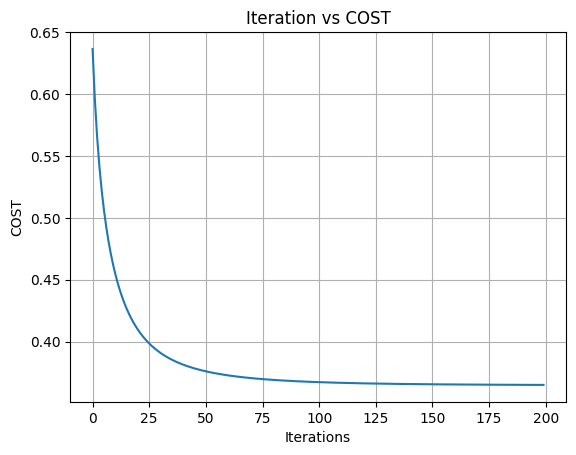

In [180]:
plt.plot(range(len(LOSS_hist)), LOSS_hist)
plt.xlabel("Iterations")
plt.ylabel("COST")
plt.title("Iteration vs COST")
plt.grid(True)
plt.show()

In [181]:
y_pred = predict(X_test, w_f, b_f)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [182]:
print("Precision:", precision)



Precision: 0.7138039026740545


In [183]:
print("Recall:", recall)


Recall: 0.4724170918367347


In [184]:
print("F1-Score:", f1)

F1-Score: 0.5685503214045861
